# Notebook 2: Model Training
---

## Step 1: Dependencies/ENVs/Configs Injection

In [26]:
import warnings
warnings.filterwarnings('ignore')

In [27]:
import os
import sys
import shutil

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt

import kagglehub

In [28]:
pd.set_option("display.max_columns", None)

## Step 2: Load Data

In [29]:
df = pd.read_csv("../data/cleaned_data.csv")
df.sample(5)

,attendance_percentage,assignments_rate,quizzes_score,previous_grades,time_spent_on_study,extracurricular,stress_level,dropout_confidense
2970,89.13,55.06,63.53,66.7690,7.8,1,8,0.5155
2427,77.89,51.49,59.69,75.7980,11.2,0,6,0.6781
2512,55.44,65.02,69.11,61.3015,10.5,1,3,0.7249
1948,59.89,51.41,88.34,73.1415,27.5,1,7,0.6085
746,94.45,51.23,93.21,66.1700,15.4,1,7,0.4710


## Step 3: Feature Engineering

In [ ]:
numeric_features = [
    "attendance_percentage",
    "assignments_rate",
    "quizzes_score",
    "previous_grades",
    "time_spent_on_study",
    "extracurricular",
    "stress_level",
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("min_max_scaler", MinMaxScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[("num", numeric_transformer, numeric_features)],
    remainder="drop", 
)

In [31]:
X = df[numeric_features]
y = df["dropout_confidense"].values.astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Fit transformer on training data, transform both sets
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [ ]:
joblib.dump(preprocessor, "../artifacts/preprocessor.joblib")
print("Preprocessor saved as ../artifacts/preprocessor.joblib")

Preprocessor saved as preprocessor.joblib


## Step 4: Model Building & Training

In [7]:
def residual_block(x, units, dropout_rate=0.0, l2=1e-5):
    """
    A simple residual block for tabular data:
    input -> Dense -> BN -> ReLU -> Dense -> BN -> add(input) -> ReLU
    If dimensionality changes, use a linear projection for the skip.
    """
    input_shape = tf.keras.backend.int_shape(x)
    in_units = input_shape[-1]

    h = layers.Dense(units, kernel_regularizer=regularizers.l2(l2))(x)
    h = layers.BatchNormalization()(h)
    h = layers.Activation("relu")(h)
    if dropout_rate and dropout_rate > 0:
        h = layers.Dropout(dropout_rate)(h)

    h = layers.Dense(units, kernel_regularizer=regularizers.l2(l2))(h)
    h = layers.BatchNormalization()(h)

    # Match dimensions for the skip connection
    if in_units != units:
        skip = layers.Dense(units, kernel_regularizer=regularizers.l2(l2))(x)
        skip = layers.BatchNormalization()(skip)
    else:
        skip = x

    out = layers.Add()([h, skip])
    out = layers.Activation("relu")(out)
    return out

def build_resnet_mlp(input_dim,
                     initial_units=128,
                     blocks=3,
                     units_decay=0.5,
                     dropout_rate=0.1,
                     l2=1e-5):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(initial_units, kernel_regularizer=regularizers.l2(l2))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    units = initial_units
    for i in range(blocks):
        x = residual_block(x, units=int(units), dropout_rate=dropout_rate, l2=l2)
        units = max(16, int(units * units_decay))  # decay units per block

    x = layers.Reshape((1, tf.keras.backend.int_shape(x)[-1]))(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.Dropout(0.1)(x)
    out = layers.Dense(1, activation="linear")(x)  # regression

    model = models.Model(inputs=inp, outputs=out)
    return model

In [20]:
# -------------------------
# Build, compile, train
# -------------------------
tf.random.set_seed(42)
input_dim = X_train_scaled.shape[1]
model = build_resnet_mlp(input_dim,
                         initial_units=128,
                         blocks=3,
                         units_decay=0.6,
                         dropout_rate=0.1,
                         l2=1e-5)

model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
              loss="mse",
              metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 128)       │      1,024 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_33[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 128)       │     16,512 │ activation_21[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_34[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_22       │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 128)       │          0 │ activation_22[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 128)       │     16,512 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_35[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 128)       │          0 │ batch_normalizat… │
│                     │                   │            │ activation_21[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_23       │ (None, 128)       │          0 │ add_9[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_36 (Dense)    │ (None, 76)        │      9,804 │ activation_23[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 76)        │        304 │ dense_36[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_24       │ (None, 76)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 76)        │          0 │ activation_24[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_37 (Dense)    │ (None, 76)        │      5,852 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_38 (Dense)    │ (None, 76)        │      9,804 │ activation_23[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 76)        │        304 │ dense_37[0][0]  

 Total params: 74,505 (291.04 KB)

 Trainable params: 73,011 (285.20 KB)

 Non-trainable params: 1,494 (5.84 KB)

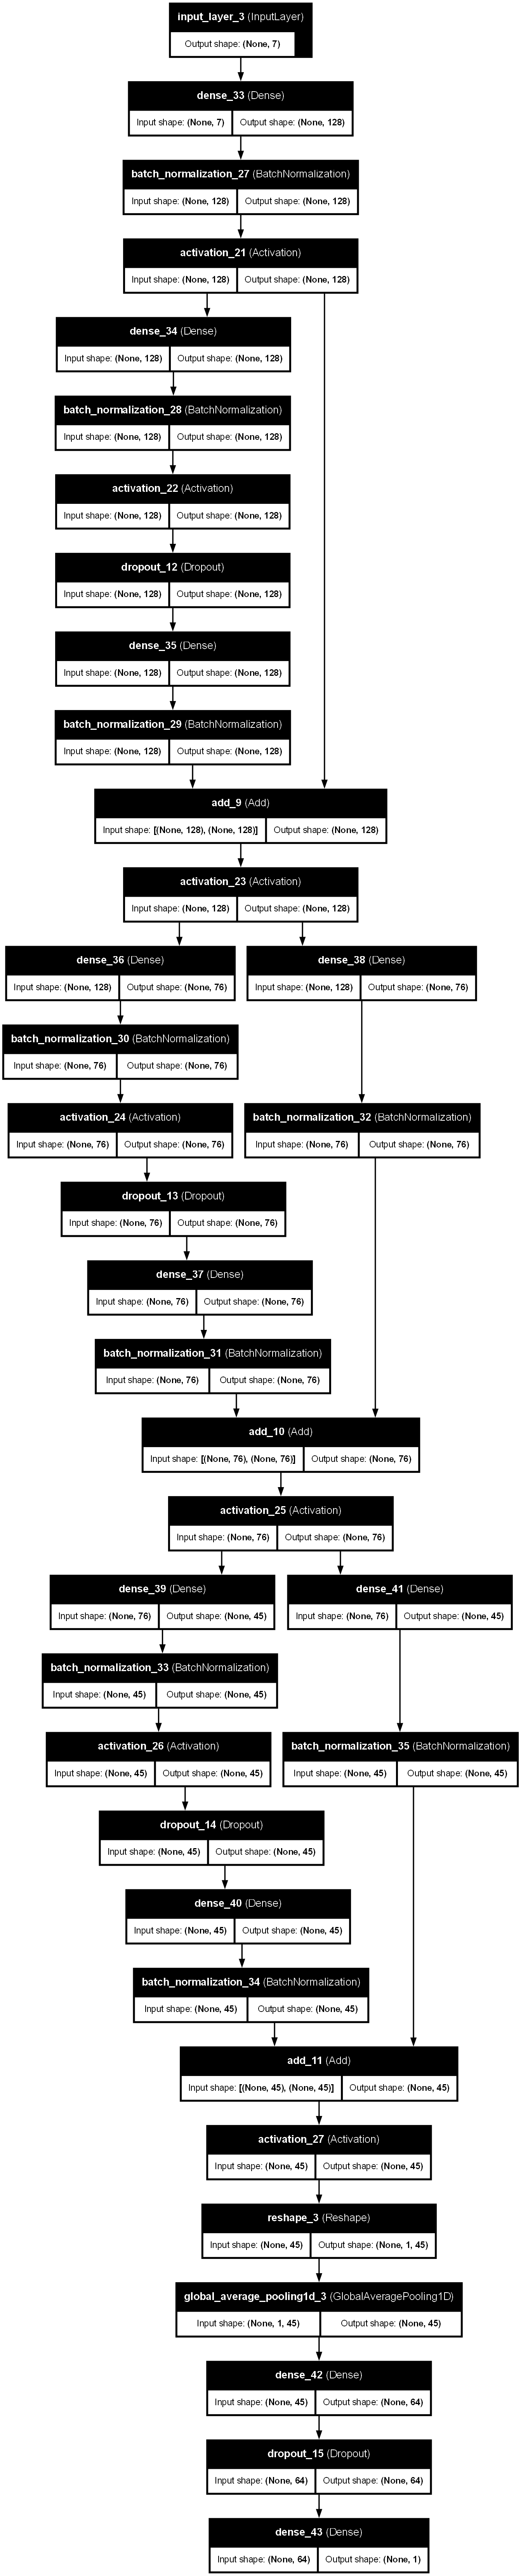

In [ ]:
plot_model(
    model,
    to_file="resnet_tabular_model.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=120
)

In [22]:
os.makedirs("../artifacts", exist_ok=True)
os.makedirs("../artifacts/checkpoints", exist_ok=True)

# Callbacks
es = callbacks.EarlyStopping(
    monitor="val_loss", 
    patience=10, 
    restore_best_weights=True, 
    verbose=1
)
chk = callbacks.ModelCheckpoint(
    "../artifacts/checkpoints/resnet_tabular_best.keras", 
    save_best_only=True, 
    monitor="val_loss", 
    verbose=1
)

In [23]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=64,
    callbacks=[es, chk],
    verbose=2
)

Epoch 1/50

Epoch 1: val_loss improved from None to 0.10490, saving model to ../artifacts/checkpoints/resnet_tabular_best.keras
54/54 - 19s - 351ms/step - loss: 0.1430 - rmse: 0.3680 - val_loss: 0.1049 - val_rmse: 0.3120
Epoch 2/50

Epoch 2: val_loss improved from 0.10490 to 0.04686, saving model to ../artifacts/checkpoints/resnet_tabular_best.keras
54/54 - 1s - 19ms/step - loss: 0.0583 - rmse: 0.2253 - val_loss: 0.0469 - val_rmse: 0.1983
Epoch 3/50

Epoch 3: val_loss improved from 0.04686 to 0.02451, saving model to ../artifacts/checkpoints/resnet_tabular_best.keras
54/54 - 2s - 29ms/step - loss: 0.0390 - rmse: 0.1774 - val_loss: 0.0245 - val_rmse: 0.1303
Epoch 4/50

Epoch 4: val_loss improved from 0.02451 to 0.02396, saving model to ../artifacts/checkpoints/resnet_tabular_best.keras
54/54 - 1s - 21ms/step - loss: 0.0307 - rmse: 0.1523 - val_loss: 0.0240 - val_rmse: 0.1282
Epoch 5/50

Epoch 5: val_loss improved from 0.02396 to 0.02037, saving model to ../artifacts/checkpoints/resnet_t

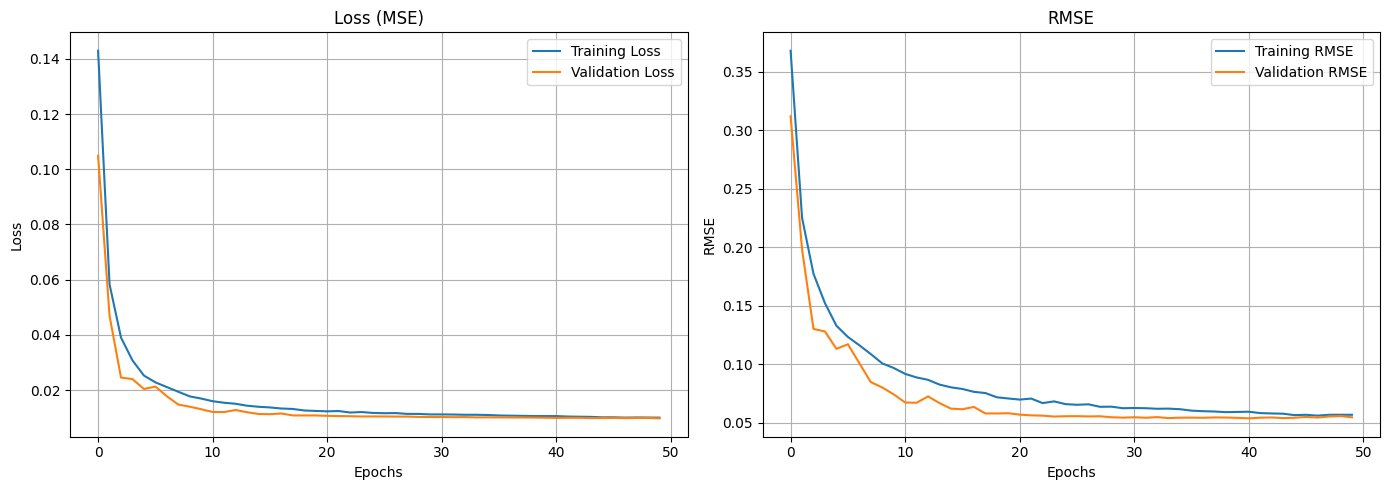

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"], label="Training Loss")
axes[0].plot(history.history["val_loss"], label="Validation Loss")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history.history["rmse"], label="Training RMSE")
axes[1].plot(history.history["val_rmse"], label="Validation RMSE")
axes[1].set_title("RMSE")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("RMSE")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()